In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql

In [2]:
df = pd.read_csv('gronagarden_data.csv')

Att göra:
Konventera "siffror" till numeriska värden
Konventera datum kolumner till dt
Städa null värden

In [5]:
def städa(v):
    v = str(v).lower()
    # 1. Dina bokstäver
    siffra_map = {'en': '1', 'ett': '1', 'två': '2', 'tre': '3', 'fyra': '4', 'fem': '5'}
    for ord, nr in siffra_map.items():
        v = v.replace(ord, nr)
    
    # 2. KG och rensning
    ggr = 1000 if 'kg' in v else 1
    s = "".join(c for c in v if c in "0123456789.,")
    
    # 3. Omvandla - allt som inte är en siffra blir 0.0 (Inga NULL!)
    try:
        return float(s.replace(',', '.')) * ggr
    except:
        return 0.0

# Kör på kolumnerna
for col in ['vikt_gram', 'pris', 'antal']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(städa)



In [6]:
def clean_datum(datum):
    if pd.isna(datum) or str(datum).lower() == 'nan':
        return pd.NaT
    
    # 1. Skapa översättningen
    manader = {
        'januari': 'january', 'februari': 'february', 'mars': 'march',
        'april': 'april', 'maj': 'may', 'juni': 'june',
        'juli': 'july', 'augusti': 'august', 'september': 'september',
        'oktober': 'october', 'november': 'november', 'december': 'december'
    }
    
    # 2. Gör till text små bokstäver och ta bort mellanslag
    d = str(datum).lower().strip()
    
    # Skapar en Series av d för att kunna använda .replace med hela ordboken direkt
    d_clean = pd.Series(d).replace(manader, regex=True).iloc[0]
    
    # 4. Gör om till datum
    return pd.to_datetime(d_clean, dayfirst=True, errors='coerce')
# Kör på datumkolumnerna
datum_cols = ['orderdatum', 'önskat_leveransdatum', 'recensionsdatum', 'faktiskt_leveransdatum']
for col in datum_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_datum)

/var/folders/29/3kf793v13_j58pg81t38xr_m0000gn/T/ipykernel_44019/592648599.py:20: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(d_clean, dayfirst=True, errors='coerce')
/var/folders/29/3kf793v13_j58pg81t38xr_m0000gn/T/ipykernel_44019/592648599.py:20: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(d_clean, dayfirst=True, errors='coerce')
/var/folders/29/3kf793v13_j58pg81t38xr_m0000gn/T/ipykernel_44019/592648599.py:20: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(d_clean, dayfirst=True, errors='coerce')
/var/folders/29/3kf793v13_j58pg81t38xr_m0000gn/T/ipykernel_44019/592648599.py:20: UserWarning: Parsing dates in %Y/%m/

In [7]:
#Städa zoner

def clean_zon(v):
    v = str(v).strip().lower()
    for i in ['1', '2', '3', '4', '5']:
        if i in v:
            return f'Zon {i}'   
    if 'norr' in v: return 'Norrland'
    if 'storstad' in v: return 'Storstad'
    if 'mellan' in v: return 'Mellansverige'
    if 'södra' in v: return 'Södra Sverige'
    return 'Okänd zon'
df_clean['leveranszon'] = df_clean['leveranszon'].apply(clean_zon)

    

In [8]:
#Städa säsonger
def clean_säsong(v):
    v = str(v).lower()
    året_runt = ['alla', 'hela året', 'all year', 'året runt']
    våren = ['vår', 'spring', 'v2024', 'april', ]
    for ord in året_runt:
        if ord in v:
            return 'Året runt'
    for ord in våren:
        if ord in v:
            return 'Våren'
    if 'höst' in v:
        return 'Hösten'
    if 'förodling' in v:
        return 'Förodling'
    return 'Okänd'
df_clean['säsong'] = df_clean['säsong'].apply(clean_säsong) 

In [78]:
#Skapa ny kolumn: Total försäljning
df_clean['total_försäljning'] = df_clean['pris'] * df_clean['antal']


In [9]:
# Sentiment analys
from transformers import pipeline

# 1. Laddar modellen
sentiment_model = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

def analyze_sentiment(text):
    if not text or str(text).lower() == 'nan':
        return 'Ingen recension'
    
    # 2. Använd samma namn här (sentiment_model) och kapa vid 510 tecken
    resultat = sentiment_model(str(text)[:510])[0]
    betyg = resultat['label']
    
    # 3. Fixa logiken för att kolla flera värden
    if betyg in ['1 star', '2 stars']:
        return 'Negativ'
    elif betyg == '3 stars':
        return 'Neutral'
    else:
        # Detta fångar upp '4 stars' och '5 stars'
        return 'Positiv'
# 4. Applicera på recensionstexten
df_clean['recensionssentiment'] = df_clean['recension_text'].apply(analyze_sentiment)



/Users/z/Documents/inlämning datascience/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2319.86it/s, Materializing param=classifier.weight]                                      


In [16]:
# --- Validering pipeline ---
# 1. Ladda filen
df_val = pd.read_csv('gronagarden_validation.csv')

# 2. Tvätta siffror (samma som förut)
for col in ['vikt_gram', 'pris', 'antal']:
    if col in df_val.columns:
        df_val[col] = df_val[col].apply(städa)

# 3. Analysera sentiment - VIKTIGT: Använd analyze_sentiment här!
df_val['recensionssentiment'] = df_val['recension_text'].apply(analyze_sentiment)

# 4. Spara till SQL
conn = sql.connect('gronagarden_data_cleaned.db')
df_val.to_sql('validation_results', conn, if_exists='replace', index=False)
conn.close()

# 5. Visa resultatet
print("Validering klar!")
print(df_val[['recension_text', 'recensionssentiment']].head(10))

Validering klar!
                                 recension_text recensionssentiment
0                                           NaN     Ingen recension
1           Skadad leverans, hälften obrukbart.             Negativ
2                                           NaN     Ingen recension
3                                           NaN     Ingen recension
4           Skadad leverans, hälften obrukbart.             Negativ
5                                           NaN     Ingen recension
6                                           NaN     Ingen recension
7  Min monstera är fantastisk, så stor och fin!             Positiv
8    Snabb leverans och bra kvalitet på jorden.             Positiv
9    Mycket dålig kommunikation om förseningen.             Negativ


In [12]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2399 entries, 0 to 2398
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                2399 non-null   str           
 1   orderrad_id             2399 non-null   str           
 2   orderdatum              2399 non-null   datetime64[us]
 3   önskat_leveransdatum    2223 non-null   datetime64[us]
 4   faktiskt_leveransdatum  2399 non-null   datetime64[us]
 5   produkt_id              2399 non-null   str           
 6   produktnamn             2399 non-null   str           
 7   kategori                2399 non-null   str           
 8   säsong                  2399 non-null   str           
 9   antal                   2399 non-null   float64       
 10  pris                    2399 non-null   float64       
 11  vikt_gram               2399 non-null   float64       
 12  leveranszon             2399 non-null   str           
 13 

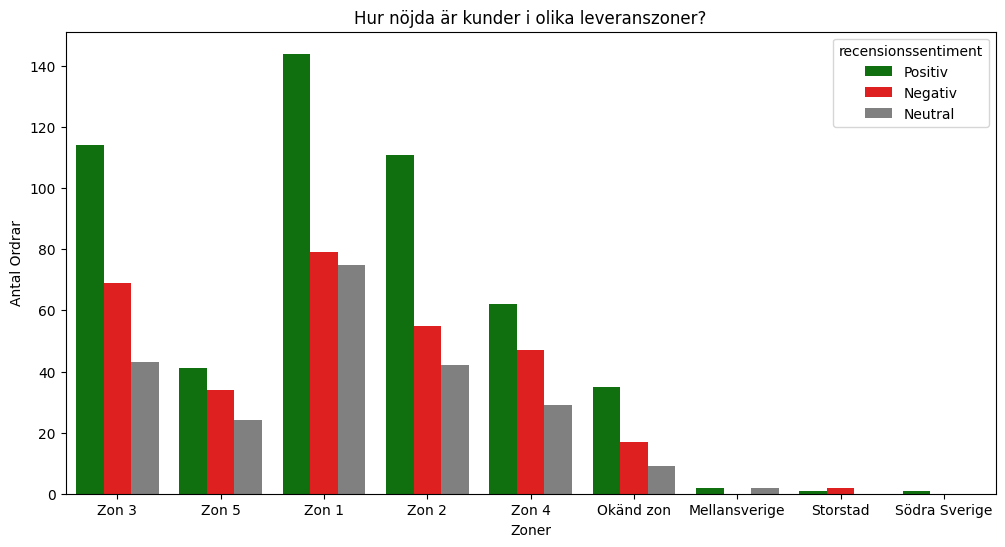

In [10]:
#Skapa graf för folk i olika zon som visar hur nöjda de är
plt.figure(figsize=(12, 6))
#Tog bort 'Ingen recension' från grafen
sns.countplot(data=df_clean[df_clean['recensionssentiment'] != 'Ingen recension'], x='leveranszon', hue='recensionssentiment', 
              palette={'Positiv': 'green', 'Neutral': 'gray', 'Negativ': 'red'})

plt.title('Hur nöjda är kunder i olika leveranszoner?')
plt.xlabel('Zoner')
plt.ylabel('Antal Ordrar')
plt.show()

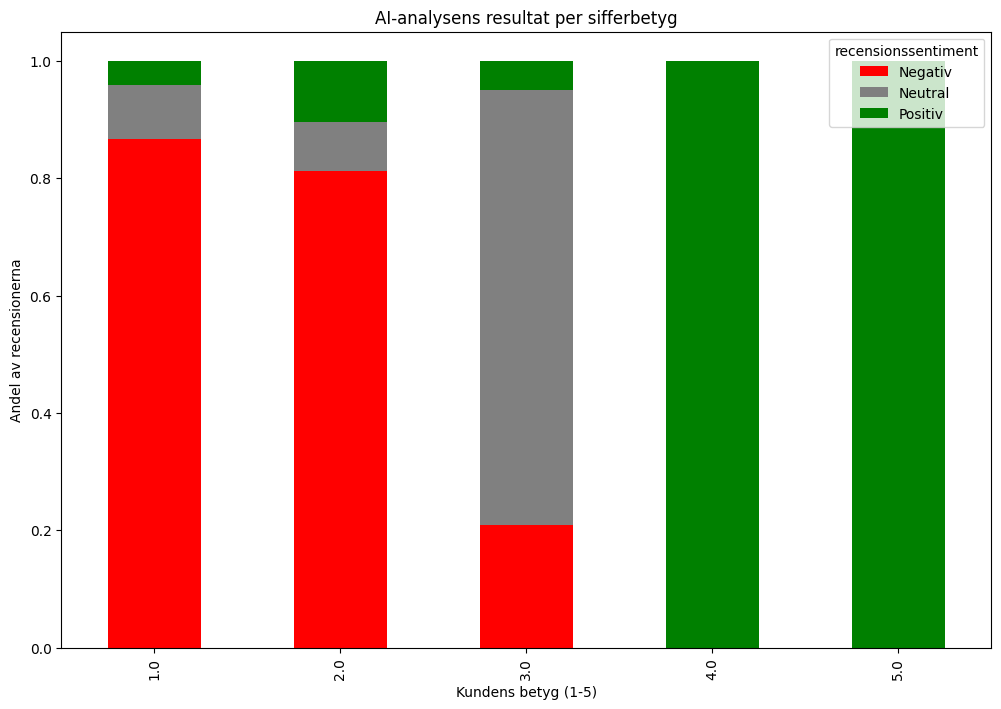

In [ ]:
# 1. Förbered data (ta bort de utan recension för att få en ren graf)
df_plot = df_clean[df_clean['recensionssentiment'] != 'Ingen recension']

# 2. Skapa grafen
# Vi grupperar på betyg och ser hur sentimentet fördelas i procent (normalize=True)
df_plot.groupby('betyg')['recensionssentiment'].value_counts(normalize=True).unstack().plot(
    kind='bar', 
    stacked=True, 
    color=['red', 'gray', 'green'],
    figsize=(12, 8)
)
plt.title('AI-analysens resultat per sifferbetyg')
plt.xlabel('Kundens betyg (1-5)')
plt.ylabel('Andel av recensionerna')
plt.show()

In [104]:
conn = sql.connect('gronagarden_data_cleaned.db')
df_clean.to_sql('gronagarden_orders', conn, if_exists='replace', index=False)
conn.close()

In [ ]:
query = """
SELECT leveranszon, recensionssentiment, COUNT(*) as antal_recensioner
FROM gronagarden_orders
WHERE recensionssentiment != 'Ingen recension'
GROUP BY leveranszon, recensionssentiment
ORDER BY leveranszon, antal_recensioner DESC
"""
print(pd.read_sql_query(query, conn))

      leveranszon recensionssentiment  antal_recensioner
0   Mellansverige             Positiv                  2
1   Mellansverige             Neutral                  2
2       Okänd zon             Positiv                 35
3       Okänd zon             Negativ                 17
4       Okänd zon             Neutral                  9
5        Storstad             Negativ                  2
6        Storstad             Positiv                  1
7   Södra Sverige             Positiv                  1
8           Zon 1             Positiv                144
9           Zon 1             Negativ                 79
10          Zon 1             Neutral                 75
11          Zon 2             Positiv                111
12          Zon 2             Negativ                 55
13          Zon 2             Neutral                 42
14          Zon 3             Positiv                114
15          Zon 3             Negativ                 69
16          Zon 3             N